In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [2]:
# Base dataset
df = pd.read_csv("../Data/Processed/renttherunway_clean.csv")

# GMM clusters
gmm = pd.read_csv("../Data/Processed/gmm_df.csv")[["user_id", "item_id", "body_cluster", "cluster_confidence"]]

# DBSCAN clusters
dbscan = pd.read_csv("../Data/Processed/dbscan_df.csv")[["user_id", "dbscan_cluster"]]

# K-Means clusters
kmeans = pd.read_csv("../Data/Processed/kmeans_clusters.csv").rename(columns={"cluster": "kmeans_cluster"})

# LDA topic features
lda = pd.read_csv("../Data/Processed/renttherunway_lda_topics.csv")

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
from sklearn.naive_bayes import GaussianNB

# ── Preprocessor (same as Linear SVM, no PCA) ──────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ("num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES
        ),
        ("topics",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            TOPIC_FEATURES
        ),
        ("cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),
        ("bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop",
    sparse_threshold=0.0
)

In [13]:
nb = GaussianNB(
    priors=[1/3, 1/3, 1/3]   # equivalent to class_weight="balanced"
)

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", nb)
])


In [14]:
param_grid = {
    "model__var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3, 1e-1]
}


In [15]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit

N_SVM = 30_000

sss = StratifiedShuffleSplit(n_splits=1, train_size=N_SVM, random_state=42)

for idx, _ in sss.split(X_train_full, y_train_full):
    X_train_nb = X_train_full.iloc[idx]
    y_train_nb = y_train_full.iloc[idx]

In [17]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_nb, y_train_nb)
best_nb = grid.best_estimator_


Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END .........................model__var_smoothing=1e-09; total time=   0.6s
[CV] END .........................model__var_smoothing=1e-09; total time=   0.6s
[CV] END .........................model__var_smoothing=1e-07; total time=   0.6s
[CV] END .........................model__var_smoothing=1e-07; total time=   0.6s
[CV] END .........................model__var_smoothing=1e-09; total time=   0.7s
[CV] END .........................model__var_smoothing=1e-07; total time=   0.7s
[CV] END .........................model__var_smoothing=1e-05; total time=   0.8s
[CV] END .........................model__var_smoothing=0.001; total time=   0.4s
[CV] END .........................model__var_smoothing=0.001; total time=   0.3s
[CV] END .........................model__var_smoothing=1e-05; total time=   0.5s
[CV] END .........................model__var_smoothing=0.001; total time=   0.4s
[CV] END .........................model__var_smoo

In [18]:
y_test_pred = best_nb.predict(X_test)

print("Best Naive Bayes parameters:")
print(grid.best_params_)

print("\nNaive Bayes — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best Naive Bayes parameters:
{'model__var_smoothing': 0.1}

Naive Bayes — Test Set Performance
              precision    recall  f1-score   support

       Small       0.18      0.27      0.22     34494
         Fit       0.80      0.43      0.56    174054
       Large       0.33      0.69      0.44     57738

    accuracy                           0.46    266286
   macro avg       0.44      0.46      0.41    266286
weighted avg       0.62      0.46      0.49    266286



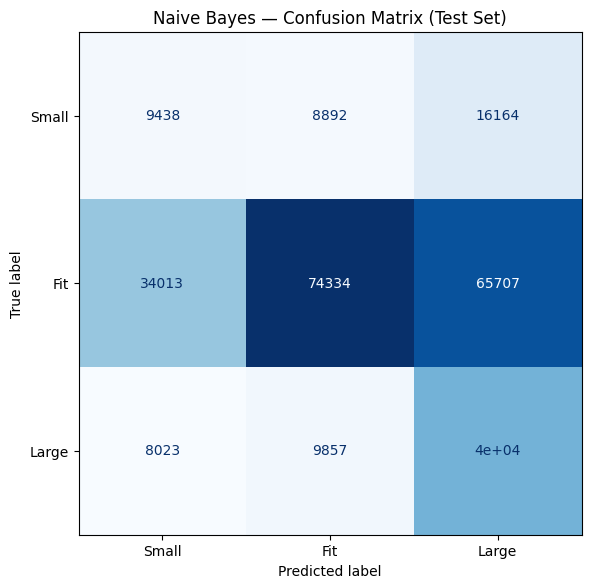

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Naive Bayes — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../figures/naive_bayes_confusion_matrix.png", dpi=300)
plt.show()

In [20]:
nb_proba = best_nb.predict_proba(X_test)   # no wrapper needed, built-in

nb_proba_df = pd.DataFrame({
    "user_id":    df.loc[X_test.index, "user_id"],
    "item_id":    df.loc[X_test.index, "item_id"],
    "true_fit":   y_test.values,
    "prob_small": nb_proba[:, 0],
    "prob_fit":   nb_proba[:, 1],
    "prob_large": nb_proba[:, 2]
})

In [21]:
nb_proba_df.to_csv(
    "../Data/Processed/naive_bayes_fit_probabilities.csv",
    index=False
)

In [22]:
import joblib
joblib.dump(best_nb, "../Models/naive_bayes_fit_classifier.joblib")


['../Models/naive_bayes_fit_classifier.joblib']

Naive Bayes trades majority-class dominance for balance. Instead of predicting "Fit" 95% of the time, it actually attempts all three classes:

Small went from recall 0.01 → 0.27 — it now detects over a quarter of small fits, vs. almost none before

Large went from recall 0.26 → 0.69 — much better at catching large fits

Fit dropped from recall 0.95 → 0.43 — it no longer over-predicts Fit


The accuracy is lower for Naive Bayes compared with SVM because the model stops blindly predicting the majority class (from Macro F1 )

var_smoothing=0.1 ==> It means the model needed a lot of smoothing to perform well, which suggests your features aren't perfectly Gaussian — body measurements and topic distributions likely have skewed distributions. Naive Bayes is making a strong assumption that doesn't fully hold.

Naive Bayes is more fair across classes than Linear SVM, but neither model is great. 

Both are likely underperforming because:
1. The features have complex, non-linear relationships (favouring kernel SVM or tree-based models)

2. Class imbalance is severe (174k Fit vs 34k Small)

3. The independence assumption in NB is violated by correlated body measurements